In [10]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import colorcet as cc

In [11]:
data2name = {
	'scrna-embryo': 'scRNA-seq (Embryo)',
	'scrna-neuro': 'scRNA-seq (Neuro)',
	'lit-adrd': 'Literature (ADRD)',
	'lit-pd1': 'Literature (PD-1)',
	'meta-gut': 'Metagenomes',
}

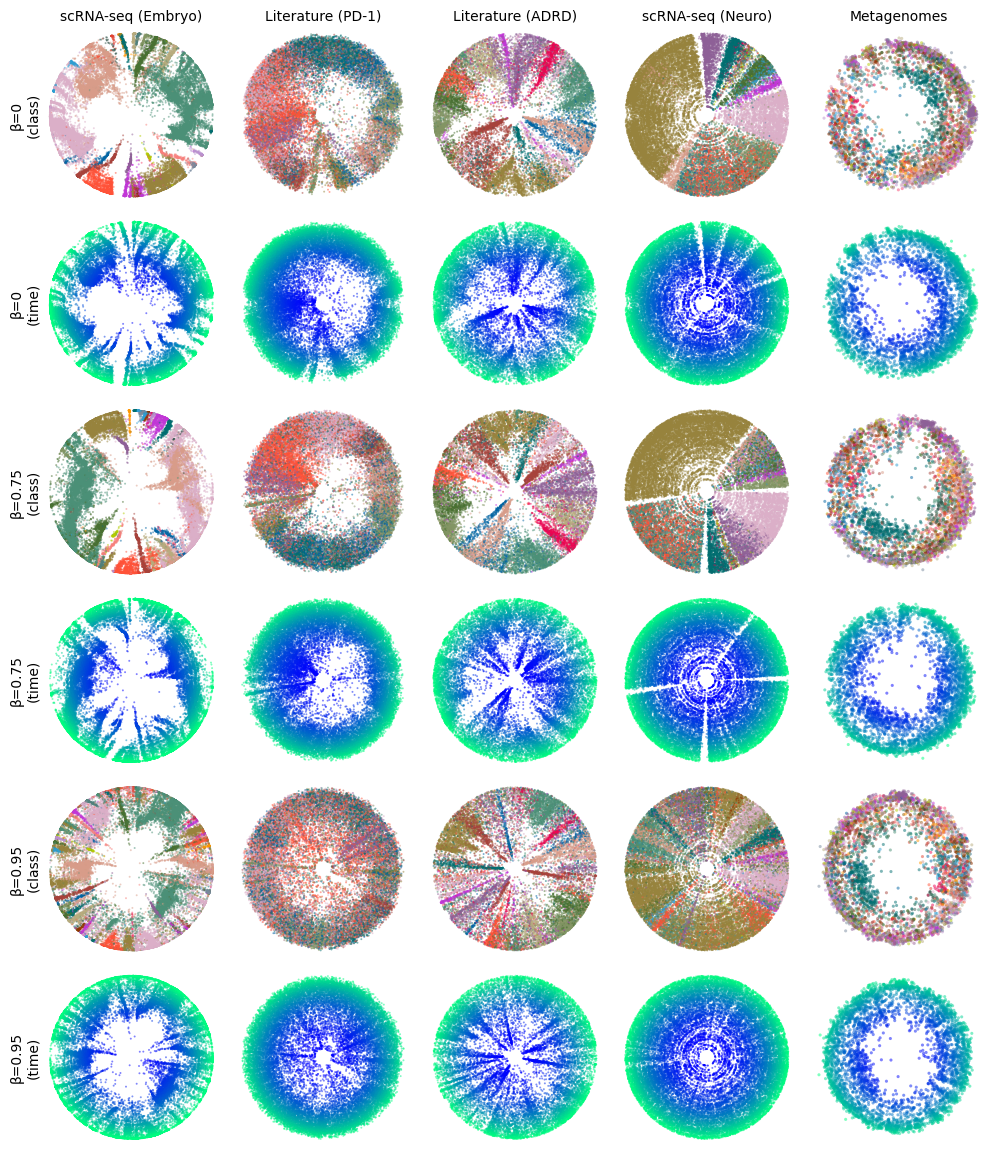

In [12]:
data2lbl = {
	'scrna-embryo': 'author_major_cell_cluster',
	'lit-pd1': 'topic',
	'lit-adrd': 'L1_clusters',
	'scrna-neuro': 'cell_type',
	'meta-gut': 'study'
}

datasets_ordered = list(data2lbl.keys())

def iris_layout(beta):
	return f'iris-b{str(beta).replace("0.", ".")}'

def layout_file(dataset, layout, rep):
	return f'../outputs/{dataset}.{layout}.r{rep}.npy'

def get_labels(dataset):
	with open(f'../data/{dataset}.meta.tsv', 'rb') as f:
		df = pd.read_csv(f, sep='\t')
	return df[data2lbl[dataset]].values

from IRIS import get_rho
from matplotlib.colors import PowerNorm

# Dataset mapping

betas = [0, 0.75, .95]
cols = len(datasets_ordered)
rows = len(betas) * 2  # Each beta gets two rows (class, time)

fig, axs = plt.subplots(rows, cols, figsize=(10, 11.5), sharex=True, sharey=True)
fig.tight_layout(pad=0.25)
plt.subplots_adjust(wspace=.1, hspace=.1)
plt.xlim(-105, 105)
plt.ylim(-105, 105)
plt.xticks(ticks=[], labels=[])
plt.yticks(ticks=[], labels=[])
sns.despine(left=True, bottom=True, top=True, right=True)

for b, beta in enumerate(betas):
    for color_type in range(2):  # 0: class/label; 1: time
        for d, dataset in enumerate(datasets_ordered):
            ax = axs[b*2 + color_type, d]
            ax.set_aspect('equal')
            file = layout_file(dataset, iris_layout(beta), 0)
            lay = np.load(open(file, 'rb'))
            t = np.load(f'../data/{dataset}.time.npy').astype(dtype=np.float32)
            lbl = get_labels(dataset)

            y = lay
            time = t
            rho = get_rho(t)
            labels = lbl
            df_plot = pd.DataFrame({
                'x': y[:,0],
                'y': y[:,1],
                'time': time.squeeze(),
                'label': labels,
                'layout': 'iris'
            })
            # Odd row: color by class; Even row: color by time
            if color_type == 0:
                # Color by class/label
                palette = sns.color_palette(list(reversed(cc.glasbey_dark)), n_colors=df_plot['label'].nunique())
                sns.scatterplot(
                    x="x", y="y", s=5 if dataset == 'meta-gut' else 2, data=df_plot.sample(frac=1, random_state=1),
                    palette=palette,
                    hue="label",
                    alpha=0.5, edgecolor='none', legend=False, ax=ax
                )
            else:
                # Color by time
                sns.scatterplot(
                    x="x", y="y", s=5 if dataset == 'meta-gut' else 2, data=df_plot.sample(frac=1, random_state=42),
                    palette='winter',
                    hue_norm=PowerNorm(np.exp(rho)*2),
                    hue="time",
                    alpha=0.5, edgecolor='none', legend=False, ax=ax
                )
            # Set titles for each column (top row, both class and time)
            if b*2 + color_type == 0:
                ax.set_title(f"{data2name[dataset]}", fontsize=10)
            # Set y-label at start of each beta group (left-most plots, each row pair)
            if d == 0:
                if color_type == 0:
                    ax.set_ylabel(f"β={beta}\n(class)", fontsize=10, visible=True)
                else:
                    ax.set_ylabel(f"β={beta}\n(time)", fontsize=10, visible=True)
plt.savefig(f'fig-beta-layouts.png', dpi=300, bbox_inches='tight')